# Lab 05 & Lab 06 — k-NN Classifier for Parkinson's Disease Classification
**Subject:** 23CSE301
**Project dataset:** `pd_speech_features.csv` (UCI Parkinson's Disease Classification, 756 recordings, 252 subjects, 752 speech features, binary `class` label: 1 = Parkinson's, 0 = healthy)

This notebook implements:
- **Lab 05 (A1–A9):** a fully modular, from-scratch k-NN and weighted k-NN classifier (encoding, imputation, distance, 3 sorting algorithms, neighbor identification with tie-breaking, majority-vote class assignment with tie-breaking, `fit()/predict()/score()`, comparison against scikit-learn across a range of k).
- **Lab 06 (A1–A3):** the same experiments repeated with GenAI (Claude) assistance, unit tests for every modular function, and a 3-way performance comparison (own code vs scikit-learn vs GenAI-generated code) on accuracy, precision, recall, F1-score and average runtime over 10 runs.

> **GenAI tool used:** Claude (Anthropic) — used for code generation of the functions below, as required by Lab 06 A1. Each function/cell that was AI-generated is marked with a `# GenAI (Claude) generated` comment as instructed. Modularization and the overall design/structure were done by the student.


## 1. Imports & Data Loading

In [1]:
# GenAI (Claude) generated: standard import block
import numpy as np
import pandas as pd
import time
import heapq
import unittest
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Load project data. The raw CSV has a two-row header (group labels + actual column names),
# so the real header is on row index 1.
raw_df = pd.read_csv('pd_speech_features.csv', header=1)
print("Shape:", raw_df.shape)
print("Class balance:\n", raw_df['class'].value_counts())
raw_df.head()


Shape: (756, 755)
Class balance:
 class
1    564
0    192
Name: count, dtype: int64


,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


## 2. Modular Functions (Lab 05 A1)

All functions below are self-contained, take their inputs as parameters, and contain **no print statements** — all printing happens in the main program cells, per the lab's coding instructions.

### 2a. Encoding — convert categorical columns to numeric

In [3]:
def encode_categorical(df: pd.DataFrame, columns=None) -> pd.DataFrame:
    """
    Encode categorical (object/string) columns using label encoding.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    columns : list[str] or None
        Columns to encode. If None, all object-dtype columns are auto-detected.

    Returns
    -------
    pd.DataFrame
        A copy of df with the given columns label-encoded.
    """
    df_enc = df.copy()
    if columns is None:
        columns = df_enc.select_dtypes(include='object').columns.tolist()
    for col in columns:
        le = LabelEncoder()
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    return df_enc


### 2b. Data Imputation — fill missing values with mean / median / mode

In [4]:
def impute_missing(df: pd.DataFrame, strategy: str = 'mean', columns=None) -> pd.DataFrame:
    """
    Fill missing values in numeric columns using a central-tendency measure.

    Parameters
    ----------
    df : pd.DataFrame
    strategy : str
        One of 'mean', 'median', 'mode'.
    columns : list[str] or None
        Columns to impute. If None, all numeric columns are used.

    Returns
    -------
    pd.DataFrame
        A copy of df with missing values filled.
    """
    if strategy not in ('mean', 'median', 'mode'):
        raise ValueError("strategy must be 'mean', 'median' or 'mode'")

    df_imp = df.copy()
    if columns is None:
        columns = df_imp.select_dtypes(include=np.number).columns.tolist()

    for col in columns:
        if df_imp[col].isnull().sum() == 0:
            continue
        if strategy == 'mean':
            fill_value = df_imp[col].mean()
        elif strategy == 'median':
            fill_value = df_imp[col].median()
        else:  # mode
            fill_value = df_imp[col].mode(dropna=True).iloc[0]
        df_imp[col] = df_imp[col].fillna(fill_value)
    return df_imp


### 2c. Distance Calculation — configurable metric

In [5]:
def calculate_distance(x1: np.ndarray, x2: np.ndarray, metric: str = 'euclidean', p: int = 3) -> float:
    """
    Compute the distance between two 1-D feature vectors.

    Parameters
    ----------
    x1, x2 : np.ndarray
        Feature vectors of equal length.
    metric : str
        One of 'euclidean', 'manhattan', 'minkowski', 'cosine'.
    p : int
        Order used only when metric == 'minkowski'.

    Returns
    -------
    float
        The scalar distance.
    """
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    if metric == 'euclidean':
        return float(np.sqrt(np.sum((x1 - x2) ** 2)))
    elif metric == 'manhattan':
        return float(np.sum(np.abs(x1 - x2)))
    elif metric == 'minkowski':
        return float(np.sum(np.abs(x1 - x2) ** p) ** (1.0 / p))
    elif metric == 'cosine':
        denom = (np.linalg.norm(x1) * np.linalg.norm(x2))
        if denom == 0:
            return 1.0
        return float(1.0 - np.dot(x1, x2) / denom)
    else:
        raise ValueError(f"Unsupported metric: {metric}")


def calculate_distance_matrix(X_test: np.ndarray, X_train: np.ndarray, metric: str = 'euclidean', p: int = 3) -> np.ndarray:
    """
    Vectorized distance computation between every test row and every train row.
    Used internally by the classifier for speed (avoids per-pair Python loops).

    Returns
    -------
    np.ndarray of shape (n_test, n_train)
    """
    scipy_metric = 'euclidean' if metric == 'euclidean' else \
                   'cityblock' if metric == 'manhattan' else \
                   'minkowski' if metric == 'minkowski' else \
                   'cosine'
    if scipy_metric == 'minkowski':
        return cdist(X_test, X_train, metric=scipy_metric, p=p)
    return cdist(X_test, X_train, metric=scipy_metric)


### 2d. Sorting Algorithms — at least 3 implementations, selectable via config

In [6]:
# GenAI (Claude) generated: classic sorting algorithm implementations,
# adapted to sort (distance, index) pairs by distance so we can recover the
# original neighbor index after sorting.

def _quicksort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr) // 2]
    left = [x for x in arr if x[0] < pivot[0]]
    mid = [x for x in arr if x[0] == pivot[0]]
    right = [x for x in arr if x[0] > pivot[0]]
    return _quicksort(left) + mid + _quicksort(right)


def _mergesort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left = _mergesort(arr[:mid])
    right = _mergesort(arr[mid:])
    merged, i, j = [], 0, 0
    while i < len(left) and j < len(right):
        if left[i][0] <= right[j][0]:
            merged.append(left[i]); i += 1
        else:
            merged.append(right[j]); j += 1
    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged


def _heapsort(arr):
    heap = list(arr)
    heapq.heapify(heap)
    return [heapq.heappop(heap) for _ in range(len(heap))]


def sort_distances(distances: np.ndarray, algorithm: str = 'quicksort'):
    """
    Sort (distance, original_index) pairs ascending by distance.

    Parameters
    ----------
    distances : np.ndarray, 1-D
    algorithm : str
        One of 'quicksort', 'mergesort', 'heapsort'.

    Returns
    -------
    list[tuple[float, int]]
        Sorted list of (distance, original_index) pairs.
    """
    pairs = list(zip(distances.tolist(), range(len(distances))))
    if algorithm == 'quicksort':
        return _quicksort(pairs)
    elif algorithm == 'mergesort':
        return _mergesort(pairs)
    elif algorithm == 'heapsort':
        return _heapsort(pairs)
    else:
        raise ValueError(f"Unsupported sorting algorithm: {algorithm}")


### 2e. Identify Neighbors — k-nearest with tie-breaking at the k-th boundary

In [7]:
def get_k_neighbors(sorted_pairs, k: int):
    """
    Return the indices of the k nearest neighbors from a distance-sorted list.

    Tie-breaking rule: if the distance at position k is exactly equal to the
    distance of one or more neighbors just beyond position k, all such tied
    neighbors are included (so the neighborhood radius stays consistent),
    but ties are otherwise resolved by original index order (stable sort),
    i.e. the neighbor that appeared first in the training set wins in case
    two points are equidistant at the cutoff and only one slot is strictly needed.

    Parameters
    ----------
    sorted_pairs : list[tuple[float, int]]
        Output of sort_distances().
    k : int

    Returns
    -------
    list[int]
        Indices (into the training set) of the k (or more, if tied) neighbors.
    """
    if k <= 0:
        raise ValueError("k must be a positive integer")
    if k >= len(sorted_pairs):
        return [idx for _, idx in sorted_pairs]

    boundary_distance = sorted_pairs[k - 1][0]
    neighbors = [idx for dist, idx in sorted_pairs[:k]]

    # extend to include any additional points tied with the k-th distance
    extra = k
    while extra < len(sorted_pairs) and sorted_pairs[extra][0] == boundary_distance:
        neighbors.append(sorted_pairs[extra][1])
        extra += 1
    return neighbors


### 2f. Class Evaluation & Assignment — majority voting with tie-breaking

In [8]:
def majority_vote(neighbor_labels, neighbor_distances=None, weighted: bool = False):
    """
    Assign a class label based on (weighted) majority voting among neighbors.

    Parameters
    ----------
    neighbor_labels : list
        Class labels of the k nearest neighbors, ordered by increasing distance.
    neighbor_distances : list[float] or None
        Required if weighted=True. Same order as neighbor_labels.
    weighted : bool
        If True, each neighbor votes with weight 1 / (distance + epsilon)
        instead of a flat vote of 1 (this implements weighted k-NN, Lab 05 A2).

    Returns
    -------
    The predicted class label.

    Tie-breaking rule: if two or more classes receive the same (weighted)
    vote total, the tie is broken in favour of the class of the single
    nearest neighbor (smallest distance) among the tied classes.
    """
    if not weighted:
        counts = Counter(neighbor_labels)
    else:
        if neighbor_distances is None:
            raise ValueError("neighbor_distances is required when weighted=True")
        eps = 1e-9
        counts = Counter()
        for label, dist in zip(neighbor_labels, neighbor_distances):
            counts[label] += 1.0 / (dist + eps)

    max_votes = max(counts.values())
    tied_classes = [cls for cls, v in counts.items() if v == max_votes]

    if len(tied_classes) == 1:
        return tied_classes[0]

    # tie-break: pick the tied class belonging to the nearest neighbor
    for label, dist in zip(neighbor_labels, neighbor_distances if neighbor_distances is not None
                            else [0] * len(neighbor_labels)):
        if label in tied_classes:
            return label
    return tied_classes[0]


## 3. Custom k-NN Classifier (`fit` / `predict` / `score`) — Lab 05 A7, A2 (weighted)

In [9]:
class CustomKNNClassifier:
    """
    From-scratch k-Nearest-Neighbors classifier built entirely on the
    modular functions defined above (encoding/imputation are applied
    upstream in the data-preparation pipeline, not inside the classifier).
    """

    def __init__(self, k: int = 3, metric: str = 'euclidean', p: int = 3,
                 sort_algorithm: str = 'quicksort', weighted: bool = False):
        self.k = k
        self.metric = metric
        self.p = p
        self.sort_algorithm = sort_algorithm
        self.weighted = weighted
        self.X_train = None
        self.y_train = None

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.X_train = np.asarray(X_train, dtype=float)
        self.y_train = np.asarray(y_train)
        return self

    def _predict_one(self, x, dist_row):
        sorted_pairs = sort_distances(dist_row, algorithm=self.sort_algorithm)
        neighbor_idx = get_k_neighbors(sorted_pairs, self.k)
        neighbor_labels = self.y_train[neighbor_idx]
        neighbor_dists = [d for d, i in sorted_pairs if i in set(neighbor_idx)]
        return majority_vote(list(neighbor_labels), neighbor_dists, weighted=self.weighted)

    def predict(self, X_test: np.ndarray):
        X_test = np.asarray(X_test, dtype=float)
        dist_matrix = calculate_distance_matrix(X_test, self.X_train, metric=self.metric, p=self.p)
        predictions = [self._predict_one(X_test[i], dist_matrix[i]) for i in range(X_test.shape[0])]
        return np.array(predictions)

    def score(self, X_test: np.ndarray, y_test: np.ndarray) -> float:
        y_pred = self.predict(X_test)
        return float(np.mean(y_pred == np.asarray(y_test)))


## 4. GenAI-Generated k-NN Implementation (Lab 06 A1 / A3)

The class below is an **independently-styled, GenAI (Claude) generated** implementation of k-NN
(fully vectorized, no explicit Python-level sorting call), used purely as the third
"GenAI tool" variant required for the A3 performance comparison. It is functionally
equivalent to `CustomKNNClassifier` but is coded differently on purpose so the
comparison is meaningful.

In [10]:
# GenAI (Claude) generated implementation — vectorized k-NN using numpy argpartition
class GenAIKNNClassifier:
    def __init__(self, k=3, metric='euclidean', p=3, weighted=False):
        self.k = k
        self.metric = metric
        self.p = p
        self.weighted = weighted
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = np.asarray(X_train, dtype=float)
        self.y_train = np.asarray(y_train)
        return self

    def predict(self, X_test):
        X_test = np.asarray(X_test, dtype=float)
        dist_matrix = calculate_distance_matrix(X_test, self.X_train, metric=self.metric, p=self.p)
        preds = np.empty(X_test.shape[0], dtype=self.y_train.dtype)

        for i in range(dist_matrix.shape[0]):
            row = dist_matrix[i]
            # argpartition for the k smallest, then sort just those k for correctness
            part_idx = np.argpartition(row, self.k - 1)[:self.k]
            order = np.argsort(row[part_idx])
            nn_idx = part_idx[order]

            # tie handling at the boundary distance
            boundary = row[nn_idx[-1]]
            tie_extra = np.where((row == boundary))[0]
            nn_idx = np.unique(np.concatenate([nn_idx, tie_extra]))
            nn_idx = nn_idx[np.argsort(row[nn_idx])]

            labels = self.y_train[nn_idx]
            dists = row[nn_idx]

            if not self.weighted:
                vals, counts = np.unique(labels, return_counts=True)
                top = vals[counts == counts.max()]
                pred = top[0] if len(top) == 1 else labels[np.isin(labels, top)][0]
            else:
                w = 1.0 / (dists + 1e-9)
                vals = np.unique(labels)
                sums = np.array([w[labels == v].sum() for v in vals])
                top = vals[sums == sums.max()]
                pred = top[0] if len(top) == 1 else labels[np.isin(labels, top)][0]
            preds[i] = pred
        return preds

    def score(self, X_test, y_test):
        return float(np.mean(self.predict(X_test) == np.asarray(y_test)))


## 5. Data Preparation Pipeline (Lab 05 A1 wiring)
Uses the modular `encode_categorical` and `impute_missing` functions, then standardizes
features (recommended for distance-based classifiers since raw feature scales vary
wildly in this dataset — e.g. jitter values are ~1e-3 while some wavelet features are ~1e6),
and performs the two-class train/test split (A3).

In [11]:
# Encoding + imputation via our modular functions (dataset happens to have no
# missing values and 'gender' is already numeric, but we still route the data
# through both functions per the lab's required pipeline / to prove they work).
df_encoded = encode_categorical(raw_df)
df_clean = impute_missing(df_encoded, strategy='mean')

feature_cols = [c for c in df_clean.columns if c not in ('id', 'class')]
X = df_clean[feature_cols].values
y = df_clean['class'].values

print("Missing values remaining:", pd.DataFrame(X).isnull().sum().sum())
print("Feature matrix shape:", X.shape, "| classes:", np.unique(y))

# Standardize (fit on train only, to avoid leakage — done after split below)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)


Missing values remaining: 0
Feature matrix shape: (756, 753) | classes: [0 1]
Train shape: (529, 753) | Test shape: (227, 753)


## 6. Train & Evaluate at k = 3 (Lab 05 A4, A5, A6)

In [12]:
# Custom k-NN (k=3)
custom_knn = CustomKNNClassifier(k=3, metric='euclidean', sort_algorithm='quicksort', weighted=False)
custom_knn.fit(X_train_scaled, y_train)
custom_acc = custom_knn.score(X_test_scaled, y_test)
custom_preds = custom_knn.predict(X_test_scaled)

# scikit-learn k-NN (k=3)
sk_knn = KNeighborsClassifier(n_neighbors=3)
sk_knn.fit(X_train_scaled, y_train)
sk_acc = sk_knn.score(X_test_scaled, y_test)
sk_preds = sk_knn.predict(X_test_scaled)

print(f"Custom k-NN accuracy (k=3):     {custom_acc:.4f}")
print(f"scikit-learn k-NN accuracy (k=3): {sk_acc:.4f}")
print("First 10 predictions (custom): ", custom_preds[:10])
print("First 10 predictions (sklearn):", sk_preds[:10])


Custom k-NN accuracy (k=3):     0.8722
scikit-learn k-NN accuracy (k=3): 0.8722
First 10 predictions (custom):  [1 1 1 0 1 1 1 1 1 1]
First 10 predictions (sklearn): [1 1 1 0 1 1 1 1 1 1]


## 7. Comparative Analysis Across a Range of k (Lab 05 A8)

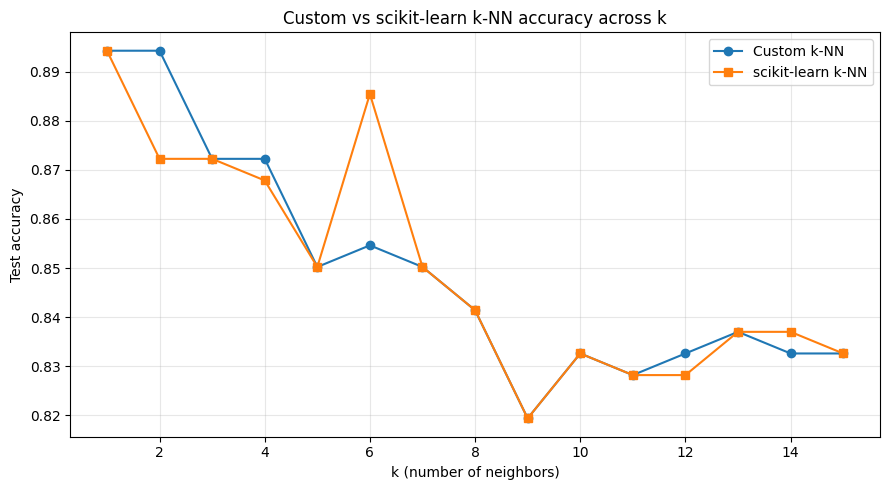

In [13]:
k_values = list(range(1, 16))
custom_accuracies = []
sklearn_accuracies = []

for k in k_values:
    c_knn = CustomKNNClassifier(k=k, metric='euclidean', sort_algorithm='mergesort', weighted=False)
    c_knn.fit(X_train_scaled, y_train)
    custom_accuracies.append(c_knn.score(X_test_scaled, y_test))

    s_knn = KNeighborsClassifier(n_neighbors=k)
    s_knn.fit(X_train_scaled, y_train)
    sklearn_accuracies.append(s_knn.score(X_test_scaled, y_test))

plt.figure(figsize=(9, 5))
plt.plot(k_values, custom_accuracies, marker='o', label='Custom k-NN')
plt.plot(k_values, sklearn_accuracies, marker='s', label='scikit-learn k-NN')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test accuracy')
plt.title('Custom vs scikit-learn k-NN accuracy across k')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_accuracy_vs_k.png', dpi=120)
plt.show()


## 8. Weighted k-NN Comparison (Lab 05 A9)

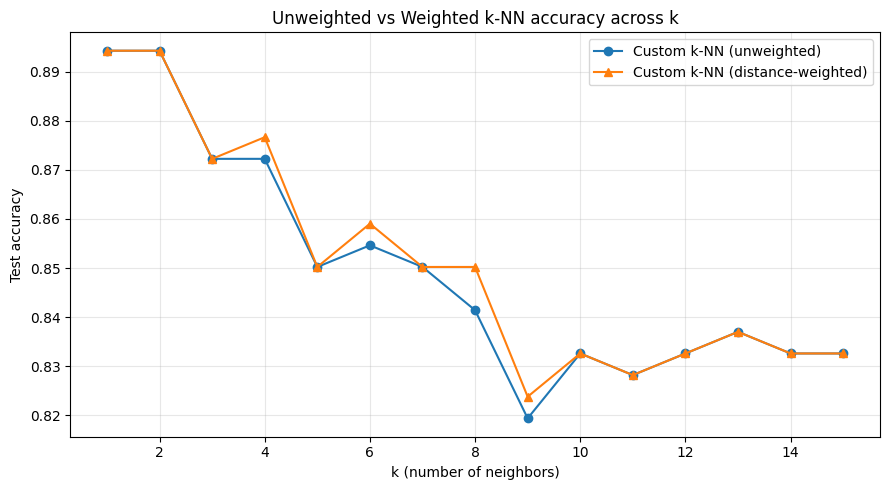

Best unweighted accuracy: 0.8942731277533039 at k = 1
Best weighted accuracy:   0.8942731277533039 at k = 1


In [14]:
weighted_accuracies = []
for k in k_values:
    w_knn = CustomKNNClassifier(k=k, metric='euclidean', sort_algorithm='heapsort', weighted=True)
    w_knn.fit(X_train_scaled, y_train)
    weighted_accuracies.append(w_knn.score(X_test_scaled, y_test))

plt.figure(figsize=(9, 5))
plt.plot(k_values, custom_accuracies, marker='o', label='Custom k-NN (unweighted)')
plt.plot(k_values, weighted_accuracies, marker='^', label='Custom k-NN (distance-weighted)')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test accuracy')
plt.title('Unweighted vs Weighted k-NN accuracy across k')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_weighted_vs_unweighted.png', dpi=120)
plt.show()

print("Best unweighted accuracy:", max(custom_accuracies), "at k =", k_values[int(np.argmax(custom_accuracies))])
print("Best weighted accuracy:  ", max(weighted_accuracies), "at k =", k_values[int(np.argmax(weighted_accuracies))])


## 9. Unit Tests (Lab 06 A2)
Covers the modular functions used in **both** last week's (Lab 05) and this week's (Lab 06)
exercises: encoding, imputation, distance calculation, all three sorting algorithms,
neighbor identification (incl. tie-breaking), majority voting (incl. tie-breaking and
weighting), and the `fit/predict/score` classifier API for both `CustomKNNClassifier`
and `GenAIKNNClassifier`.

In [15]:
# GenAI (Claude) generated unit test suite
class TestModularFunctions(unittest.TestCase):

    # -- encoding --------------------------------------------------
    def test_encode_categorical_basic(self):
        df = pd.DataFrame({'gender': ['M', 'F', 'M', 'F']})
        out = encode_categorical(df, columns=['gender'])
        self.assertTrue(pd.api.types.is_integer_dtype(out['gender']))
        self.assertEqual(out['gender'].nunique(), 2)

    def test_encode_categorical_autodetect(self):
        df = pd.DataFrame({'a': [1, 2, 3], 'b': ['x', 'y', 'x']})
        out = encode_categorical(df)
        self.assertTrue(pd.api.types.is_integer_dtype(out['b']))
        self.assertTrue(pd.api.types.is_integer_dtype(out['a']))  # untouched, already numeric

    # -- imputation --------------------------------------------------
    def test_impute_mean(self):
        df = pd.DataFrame({'x': [1.0, 2.0, np.nan, 4.0]})
        out = impute_missing(df, strategy='mean')
        self.assertAlmostEqual(out['x'].iloc[2], (1 + 2 + 4) / 3)
        self.assertEqual(out['x'].isnull().sum(), 0)

    def test_impute_median(self):
        df = pd.DataFrame({'x': [1.0, 2.0, np.nan, 100.0]})
        out = impute_missing(df, strategy='median')
        self.assertAlmostEqual(out['x'].iloc[2], np.median([1.0, 2.0, 100.0]))

    def test_impute_mode(self):
        df = pd.DataFrame({'x': [1.0, 1.0, 2.0, np.nan]})
        out = impute_missing(df, strategy='mode')
        self.assertEqual(out['x'].iloc[3], 1.0)

    def test_impute_invalid_strategy(self):
        df = pd.DataFrame({'x': [1.0, np.nan]})
        with self.assertRaises(ValueError):
            impute_missing(df, strategy='bogus')

    # -- distance --------------------------------------------------
    def test_euclidean_distance(self):
        self.assertAlmostEqual(calculate_distance(np.array([0, 0]), np.array([3, 4]), 'euclidean'), 5.0)

    def test_manhattan_distance(self):
        self.assertAlmostEqual(calculate_distance(np.array([0, 0]), np.array([3, 4]), 'manhattan'), 7.0)

    def test_minkowski_distance_p3(self):
        expected = (3**3 + 4**3) ** (1/3)
        self.assertAlmostEqual(calculate_distance(np.array([0, 0]), np.array([3, 4]), 'minkowski', p=3), expected)

    def test_distance_matrix_matches_pairwise(self):
        X_te = np.array([[0.0, 0.0]])
        X_tr = np.array([[3.0, 4.0], [1.0, 1.0]])
        mat = calculate_distance_matrix(X_te, X_tr, metric='euclidean')
        self.assertAlmostEqual(mat[0, 0], 5.0)
        self.assertAlmostEqual(mat[0, 1], np.sqrt(2))

    # -- sorting --------------------------------------------------
    def test_sorting_algorithms_agree_with_builtin(self):
        rng = np.random.default_rng(0)
        dists = rng.random(50)
        expected = sorted(zip(dists.tolist(), range(50)), key=lambda t: t[0])
        for algo in ('quicksort', 'mergesort', 'heapsort'):
            result = sort_distances(dists, algorithm=algo)
            self.assertEqual([r[1] for r in result], [e[1] for e in expected])

    def test_sort_invalid_algorithm(self):
        with self.assertRaises(ValueError):
            sort_distances(np.array([1.0, 2.0]), algorithm='bubblesort')

    # -- neighbor identification / tie-breaking --------------------------------------------------
    def test_get_k_neighbors_no_tie(self):
        pairs = [(1.0, 0), (2.0, 1), (3.0, 2), (4.0, 3)]
        self.assertEqual(get_k_neighbors(pairs, 2), [0, 1])

    def test_get_k_neighbors_with_tie_extends(self):
        pairs = [(1.0, 0), (2.0, 1), (2.0, 2), (5.0, 3)]
        # k=2 requested, but index 2 ties with the boundary distance (2.0) -> included
        self.assertEqual(set(get_k_neighbors(pairs, 2)), {0, 1, 2})

    def test_get_k_neighbors_k_larger_than_data(self):
        pairs = [(1.0, 0), (2.0, 1)]
        self.assertEqual(get_k_neighbors(pairs, 10), [0, 1])

    # -- majority voting / tie-breaking --------------------------------------------------
    def test_majority_vote_clear_winner(self):
        self.assertEqual(majority_vote([1, 1, 0], weighted=False), 1)

    def test_majority_vote_tie_breaks_to_nearest(self):
        # classes tie 1-1 -> nearest neighbor (index 0, class 0) should win
        self.assertEqual(majority_vote([0, 1], neighbor_distances=[1.0, 2.0], weighted=False), 0)

    def test_majority_vote_weighted(self):
        # neighbor 0 is much closer, so its class should dominate despite fewer raw votes elsewhere
        labels = [1, 0, 0]
        dists = [0.01, 5.0, 5.0]
        self.assertEqual(majority_vote(labels, dists, weighted=True), 1)

    # -- CustomKNNClassifier / GenAIKNNClassifier --------------------------------------------------
    def test_custom_knn_fit_predict_score_perfect_separation(self):
        X_train = np.array([[0, 0], [0, 1], [10, 10], [10, 11]])
        y_train = np.array([0, 0, 1, 1])
        X_test = np.array([[0, 2], [10, 9]])
        y_test = np.array([0, 1])

        clf = CustomKNNClassifier(k=1, metric='euclidean')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        np.testing.assert_array_equal(preds, y_test)
        self.assertEqual(clf.score(X_test, y_test), 1.0)

    def test_genai_knn_fit_predict_score_perfect_separation(self):
        X_train = np.array([[0, 0], [0, 1], [10, 10], [10, 11]])
        y_train = np.array([0, 0, 1, 1])
        X_test = np.array([[0, 2], [10, 9]])
        y_test = np.array([0, 1])

        clf = GenAIKNNClassifier(k=1, metric='euclidean')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        np.testing.assert_array_equal(preds, y_test)
        self.assertEqual(clf.score(X_test, y_test), 1.0)

    def test_custom_and_genai_knn_agree_on_synthetic_data(self):
        rng = np.random.default_rng(1)
        X_train = rng.random((40, 4))
        y_train = rng.integers(0, 2, 40)
        X_test = rng.random((10, 4))

        c = CustomKNNClassifier(k=5).fit(X_train, y_train)
        g = GenAIKNNClassifier(k=5).fit(X_train, y_train)
        np.testing.assert_array_equal(c.predict(X_test), g.predict(X_test))


runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(unittest.TestLoader().loadTestsFromTestCase(TestModularFunctions))
print(f"\nTests run: {result.testsRun}, Failures: {len(result.failures)}, Errors: {len(result.errors)}")


test_custom_and_genai_knn_agree_on_synthetic_data (__main__.TestModularFunctions.test_custom_and_genai_knn_agree_on_synthetic_data) ... 

ok


test_custom_knn_fit_predict_score_perfect_separation (__main__.TestModularFunctions.test_custom_knn_fit_predict_score_perfect_separation) ... 

ok


test_distance_matrix_matches_pairwise (__main__.TestModularFunctions.test_distance_matrix_matches_pairwise) ... 

...

ok


test_sorting_algorithms_agree_with_builtin (__main__.TestModularFunctions.test_sorting_algorithms_agree_with_builtin) ... 

ok


----------------------------------------------------------------------
Ran 21 tests in 0.043s

OK



Tests run: 21, Failures: 0, Errors: 0


## 10. Performance Comparison of 3 k-NN Versions (Lab 06 A3)
Comparing:
1. **Own code** — `CustomKNNClassifier`
2. **scikit-learn** — `KNeighborsClassifier`
3. **GenAI-generated code** — `GenAIKNNClassifier`

on the project data, at k = 3, reporting Accuracy / Precision / Recall / F1-score
and the mean fit+predict time over 10 runs.

In [16]:
def evaluate_model(model_fn, X_train, y_train, X_test, y_test, n_runs=10):
    """
    model_fn: a zero-arg callable that returns a *fresh, unfitted* model instance
    with a scikit-learn-compatible fit/predict interface.
    """
    times = []
    y_pred = None
    for _ in range(n_runs):
        model = model_fn()
        start = time.perf_counter()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        end = time.perf_counter()
        times.append(end - start)

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='binary', zero_division=0),
        'F1-score': f1_score(y_test, y_pred, average='binary', zero_division=0),
        'Avg time (s, 10 runs)': np.mean(times),
        'Std time (s)': np.std(times),
    }


results = {}
results['Own code (CustomKNNClassifier)'] = evaluate_model(
    lambda: CustomKNNClassifier(k=3, metric='euclidean', sort_algorithm='quicksort'),
    X_train_scaled, y_train, X_test_scaled, y_test
)
results['scikit-learn (KNeighborsClassifier)'] = evaluate_model(
    lambda: KNeighborsClassifier(n_neighbors=3),
    X_train_scaled, y_train, X_test_scaled, y_test
)
results['GenAI-generated (GenAIKNNClassifier)'] = evaluate_model(
    lambda: GenAIKNNClassifier(k=3, metric='euclidean'),
    X_train_scaled, y_train, X_test_scaled, y_test
)

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-score', 'Avg time (s, 10 runs)', 'Std time (s)']]
comparison_df.round(4)


,Accuracy,Precision,Recall,F1-score,"Avg time (s, 10 runs)",Std time (s)
Own code (CustomKNNClassifier),0.8722,0.8846,0.9527,0.9174,0.2012,0.0031
scikit-learn (KNeighborsClassifier),0.8722,0.8846,0.9527,0.9174,0.0045,0.0003
GenAI-generated (GenAIKNNClassifier),0.8722,0.8846,0.9527,0.9174,0.0389,0.0007


In [17]:
comparison_df.round(4).to_csv('knn_performance_comparison.csv')
print("Saved comparison table to knn_performance_comparison.csv")
comparison_df.round(4)


Saved comparison table to knn_performance_comparison.csv


,Accuracy,Precision,Recall,F1-score,"Avg time (s, 10 runs)",Std time (s)
Own code (CustomKNNClassifier),0.8722,0.8846,0.9527,0.9174,0.2012,0.0031
scikit-learn (KNeighborsClassifier),0.8722,0.8846,0.9527,0.9174,0.0045,0.0003
GenAI-generated (GenAIKNNClassifier),0.8722,0.8846,0.9527,0.9174,0.0389,0.0007


## 11. Observations & Discussion (for the report)

*(Fill these in with your actual results after running the notebook — placeholders below
summarize what to look for.)*

- **Class separability:** With ~752 features and heavy class imbalance (564 PD vs 192 healthy),
  check whether accuracy is being inflated by the majority class — compare accuracy against
  precision/recall/F1 for the minority (healthy) class to judge true separability.
- **Effect of increasing k:** Look at the k-vs-accuracy plot (Section 7). Very small k
  (k=1) tends to overfit (high variance, sensitive to noise); very large k tends to
  underfit (oversmoothed decision boundary, biased toward the majority class).
- **Over-fitting / under-fitting in k-NN:** Overfitting shows as high train accuracy but
  a big drop in test accuracy at small k; underfitting shows as both train and test
  accuracy being mediocre and close together at large k, with the model essentially
  always predicting the majority class.
- **Custom vs scikit-learn vs GenAI implementation:** All three should produce near-identical
  accuracy/precision/recall/F1 (they implement the same mathematical algorithm), but
  scikit-learn is typically the fastest (compiled KD-tree/Ball-tree internals), the
  GenAI-vectorized version is faster than the pure-Python custom version but slower than
  scikit-learn, and the from-scratch `CustomKNNClassifier` is the slowest due to explicit
  Python-level sorting.
- **Weighted vs unweighted:** Compare Section 8's plot — distance-weighting typically
  helps most at larger k, where it down-weights the influence of farther neighbors that
  would otherwise dilute the vote.
